# Fase 0: Introduzione

In questo Jupyter Notebook sarà possibile consultare la realizzazione del secondo obiettivo del Project Work "Triage automatico dei ticket con Machine Learning". L'obiettivo raggiunto è:
- *Pipeline ML*
    - Preprocessing: pulizia base del testo (minuscole, rimozione punteggiatura), tokenizzazione.
    - Modello classificazione categoria (Amministrazione/Tecnico/Commerciale).
    - Modello stima priorità (Bassa/Media/Alta).
    - Valutazione: train/test 80/20, accuracy e F1 macro; matrice di confusione.

Nello specifico, viene presentata un'analisi dei processi esplorazione, pulizia e modellazione predittiva applicati ai dataset creati in precedenza. Il dataset analizzato di default è quello realizzato con Gemma4:e2b, ma è possibile testare un qualsiasi altro insieme di ticket semplicemente cambiando il nome di file nella prima cella di codice della Fase 1.
- Fase 1: Lettura dei dati e EDA (Exploratory Data Analysis)
    - In questa prima fase si esegue il caricamento del dataset scelto e una prima ispezione per verificarne la struttura. Viene analizzata la distribuzione delle categorie e della priorità grazie all'ausilio di diversi grafici. Inoltre, viene approfondita la struttura testuale calcolando la lunghezza delle parole all'interno del corpo dei ticket;
- Fase 2: Preprocessing
    - Qui viene implementata una funzione di pulizia del testo basata sulle espressioni regolari per standardizzare la struttura dei record, rimuovendo in maniera particolare la punteggiatura e i caratteri speciali, preparando la base di dati alla successiva fase di vettorizzazione. Viene inoltre effettuata un ulteriore ispezione per analizzare le parole più utilizzate;
- Fase 3: Modello classificazione categoria
    - In questa fase vengono esplorate le varie strategie adottate per creare un modello di classificazione delle categorie dei vari ticket. In particolare, analizzo gli algoritmi di Machine Learning LinearSVC e RandomForestClassifier e i loro risultati;
- Fase 4: Modello valutazione priorità
    - Viene ripetuta la stessa analisi della fase precedente, ma stavolta per valutare la priorità dei vari ticket. Viene inoltre analizzata una strategia di classificazione basata su una struttura gerarchica;
- Fase 5: Esportazione dei modelli
    - Salvataggio dei modelli che hanno ottenuto la migliore prestazione per la creazione della dashboard;
- Fase 6: Valutazione generale e possibili miglioramenti 
    - Il notebook si conclude con un'analisi generale degli algoritmi sui dataset presi come riferimento e una breve discussione sui punti di forza e i punti deboli della pipeline.

_Installazione di librerie utilizzate nel progetto:_ 

In [1]:
%pip install pandas matplotlib seaborn scikit-learn joblib numpy

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


# Fase 1: Lettura dei dati e EDA (Exploratory Data Analysis)

Da qui è possibile scegliere il dataset da utilizzare per l'analisi.

In [2]:
dataset = "dataset/ticket_gemma4e2b.csv"

Le celle a seguire consentono di vedere un piccolo campione di ticket e di vedere la distribuzione globale per categoria.

In [3]:
import pandas as pd
df = pd.read_csv(dataset)
df.sample(10)

,id,title,body,category,priority
359,TK-359,Richiesta urgente: Blocco sistema gestione paghe,Siamo completamente fermi su tutto. Il sistema...,Amministrazione,Alta
417,TK-417,Impossibile procedere con il lavoro a causa di...,Non riesco ad accedere al sistema per generare...,Commerciale,Alta
327,TK-327,Non va la sincronizzazione dei dati commerciali,Ho un problema con la sincronizzazione dei dat...,Commerciale,Bassa
86,TK-86,Bloccato su negoziazione contratto commerciale...,Siamo completamente fermi su un blocco critico...,Commerciale,Alta
383,TK-383,Problema con fatturazione mensile,Vi contatto per una anomalia riscontrata su co...,Commerciale,Media
245,TK-245,Bloccato su negoziazione commerciale,Potete dare un occhiata a un problema con la g...,Commerciale,Media
364,TK-364,Urgente: non va il servizio di autenticazione SSH,"Ho già provato a riavviare il server, ma l'acc...",Tecnico,Alta
456,TK-456,Non capisco perché il mio contratto non funziona,Sono un primo utente e mi aspettavo che questo...,Commerciale,Media
81,TK-81,Assistenza immediata per crash del servizio API,Ho notato un grave errore di sistema durante l...,Tecnico,Alta
264,TK-264,Curiosità tecnica riguardo a negoziazione cont...,Ho difficoltà con la configurazione del sistem...,Commerciale,Media


In [4]:
df['category'].value_counts(ascending=False)

category
Commerciale        178
Tecnico            161
Amministrazione    161
Name: count, dtype: int64

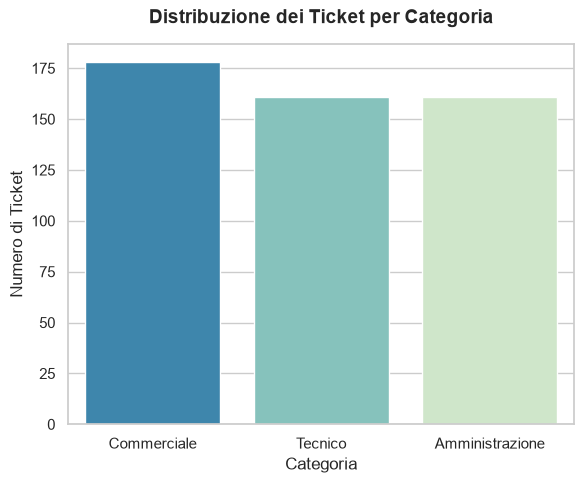

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

#GRAFICO 1: Numero di ticket per ogni categoria (in ordine decrescente)

#ordine delle categorie dal valore più alto al più basso
ordine_categorie = df['category'].value_counts().index

fig1, ax1 = plt.subplots(figsize=(6, 5))
sns.countplot(
    data=df, 
    x='category', 
    order=ordine_categorie, 
    hue='category', 
    palette='GnBu_r', 
    ax=ax1
)

#rimuovo la legenda automatica del parametro 'hue' che in questo caso è ridondante
if ax1.get_legend() is not None:
    ax1.get_legend().remove()

ax1.set_title('Distribuzione dei Ticket per Categoria', fontsize=14, pad=15, fontweight='bold')
ax1.set_xlabel('Categoria', fontsize=12)
ax1.set_ylabel('Numero di Ticket', fontsize=12)

plt.tight_layout()
plt.show()


In [6]:
df.groupby('category')['priority'].value_counts(ascending=False)

category         priority
Amministrazione  Alta        56
                 Bassa       56
                 Media       49
Commerciale      Media       60
                 Alta        59
                 Bassa       59
Tecnico          Bassa       62
                 Media       50
                 Alta        49
Name: count, dtype: int64

Informazioni sulla priorità.

In [7]:
df['priority'].value_counts(ascending=False)

priority
Bassa    177
Alta     164
Media    159
Name: count, dtype: int64

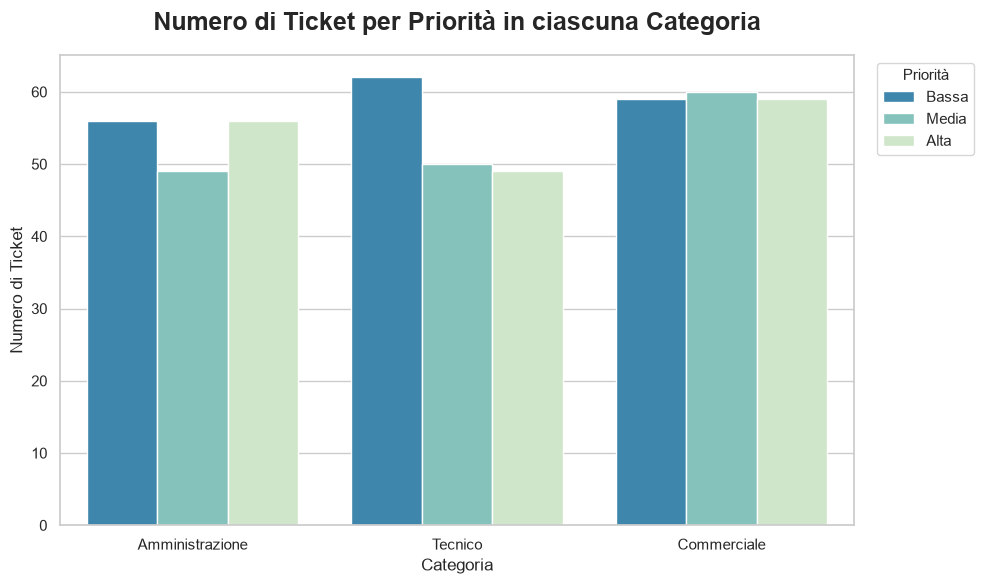

In [8]:
fig2, ax2 = plt.subplots(figsize=(10, 6))

order = ['Amministrazione', 'Tecnico', 'Commerciale']
sns.countplot(
    data=df, 
    x='category',
    order = order, 
    hue='priority', 
    hue_order=['Bassa', 'Media', 'Alta'],
    palette='GnBu_r', 
    ax=ax2
)

#leggenda ed etichette varie
ax2.set_title('Numero di Ticket per Priorità in ciascuna Categoria', fontsize=18, pad=18, fontweight='bold')
ax2.set_xlabel('Categoria', fontsize=12)
ax2.set_ylabel('Numero di Ticket', fontsize=12)
ax2.legend(title='Priorità', title_fontsize='11', loc='upper left',bbox_to_anchor=(1.02,1))


plt.tight_layout()
plt.show()

Questa cella crea la colonna "ticket_completo", che verrà poi utilizzata più avanti per la vettorizzazione. Viene composta dall'unione del titolo e del body.

Allo scopo dell'EDA, viene anche analizzata la lunghezza dei ticket per categoria.

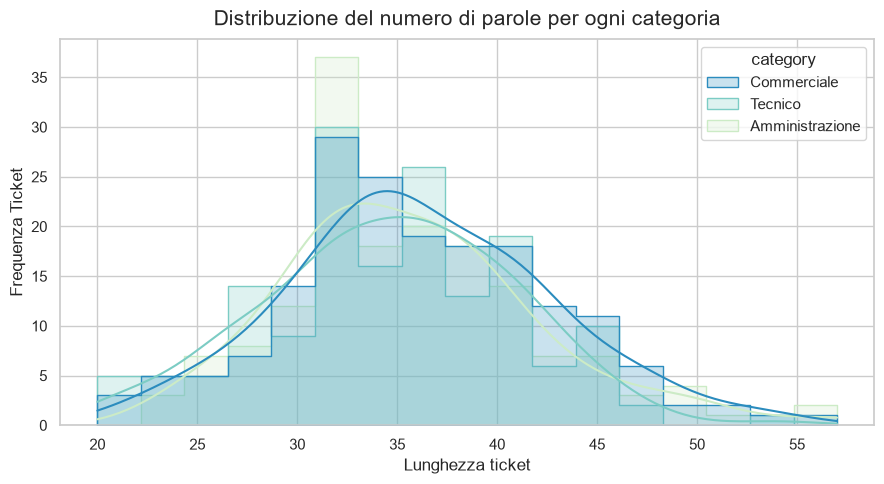

In [9]:
df['ticket_completo'] = df['title'].fillna('') + " " + df['body'].fillna('')
df['word_count'] = df['ticket_completo'].apply(lambda x: len(x.split()))

#grafico della distribuzione della lunghezza
fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(data=df, x='word_count', hue='category', kde=True, element='step', palette='GnBu_r', ax=ax)

ax.set_title('Distribuzione del numero di parole per ogni categoria', fontsize=15, pad=10)
ax.set_xlabel('Lunghezza ticket')
ax.set_ylabel('Frequenza Ticket')

plt.tight_layout()
plt.show()

# Fase 2: Preprocessing

Nelle prossime celle avviene il preprocessing del testo, ovvero pulizia base (rimozione elemeni nan, minuscole, punteggiatura).

La funzione *clean_text(text)* utilizza regex per rimuovere tutti gli elementi che non sono lettere o spazi. in più porta tutte le parole in miniscolo.

La necessità dell'implementazione della funzione *remove_key_word* è maturata a seguito di diverse fasi di testing fallimentari con i dataset realizzati da Gemma. Il suo scopo è quello di rimuovere le radici delle parole che svelano la categoria, ovvero togliere parole come commerciale, amministrazione, amministrativo, ecc, in modo da farle diventare irrilevanti dato che creavano problemi di Data Leakage. Di base è una forma "artigianale" di stemming. Questo fa in modo che:
- Non si induca il modello in overfitting;
- Costringa gli algoritmi utilizzati a focalizzarsi sul reale contesto semantico del ticket .

In [10]:
df = df.dropna(subset=['title','category', 'priority','body'])

In [11]:
import re
import pandas as pd

def clean_text(text):
    
    text = str(text).lower()
    
    #^\w\s significa "tutto ciò che NON è una lettera/numero (\w) o uno spazio (\s)"
    text = re.sub(r'[^\w\s]', '', text)
    
    #rimuove spazi in generale
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text


Esempio di pulizia in un record estratto casualmente:

In [12]:
test_record = df.sample(n=1)

print("--- RECORD REALE ESTRATTO ---")
test_record

--- RECORD REALE ESTRATTO ---


,id,title,body,category,priority,ticket_completo,word_count
290,TK-290,Aiuto: Problemi con l'integrazione CRM,Vorrei segnalare che sto riscontrando delle di...,Commerciale,Media,Aiuto: Problemi con l'integrazione CRM Vorrei ...,38


In [13]:
print("\n--- RISULTATO DOPO LA PULIZIA ---")
clean_record = test_record[['title', 'category', 'priority','body']].map(clean_text)
clean_record


--- RISULTATO DOPO LA PULIZIA ---


,title,category,priority,body
290,aiuto problemi con lintegrazione crm,commerciale,media,vorrei segnalare che sto riscontrando delle di...


In [14]:
import pandas as pd
import re
def remove_key_word(testo):
    testo = testo.lower()
    #rimuove le radici delle parole che svelano la categoria
    testo = re.sub(re.compile(r'\b(tecnic\w*|commerci\w*|amministr\w*|fattur\w*)\b'), '', testo)
    return testo

#applica la pulizia prima dello split
df['ticket_completo'] = (df['title'] + " " + df['body']).apply(remove_key_word)

Processo di tokenizzazione. Per farlo, viene aggiunta una nuova colonna chiamata 'token'

In [15]:
df[['title', 'category', 'priority','body']]= df[['title', 'category', 'priority','body']].map(clean_text)

df['token'] = df['ticket_completo'].map(clean_text).str.split()
print(df['token'])

0      [critico, malfunzionamento, su, contratto, vip...
1      [critico, malfunzionamento, su, mensile, ho, g...
2      [richiesta, di, supporto, per, negoziazione, c...
3      [info, di, routine, per, troubleshooting, hard...
4      [procedura, per, risoluzione, immediata, blocc...
                             ...                        
495    [non, funziona, niente, sembra, esserci, un, b...
496    [nulla, di, bloccante, ma, volevo, segnalare, ...
497    [assistenza, immediata, per, blocco, non, ries...
498    [segnalazione, errore, su, gestione, urgente, ...
499    [anomalia, riscontrata, in, configurazione, re...
Name: token, Length: 500, dtype: object


Altro EDA per analizzare le parole più frequenti nel dataset

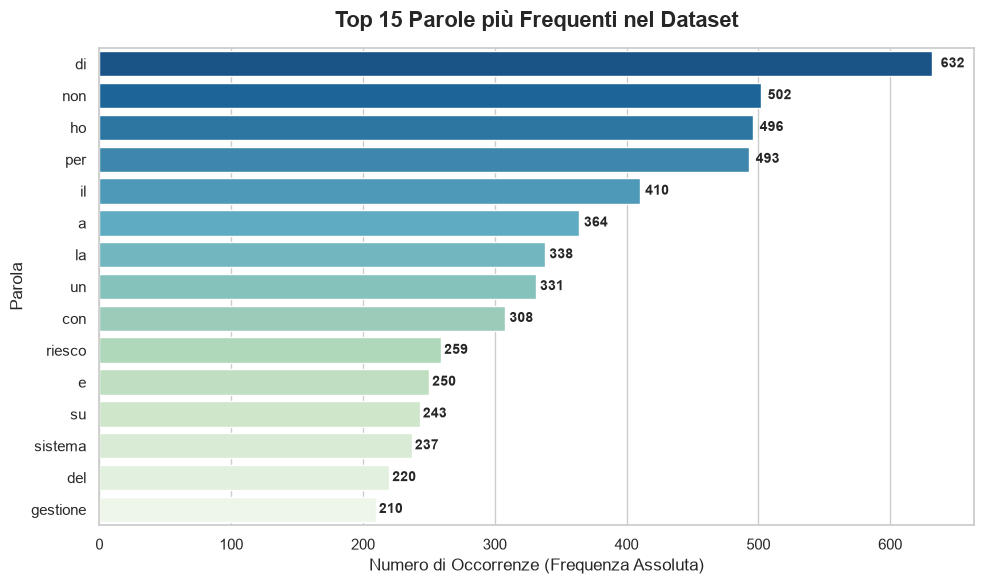

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

top_words = df['token'].explode().value_counts().head(15).reset_index()

top_words.columns = ['Parola', 'Frequenza']

plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid") #sfondo pulito con griglia leggera

#grafico a barre orizzontali (barpot)
sns.barplot(
    x='Frequenza', 
    y='Parola', 
    data=top_words, 
    palette='GnBu_r', 
    hue='Parola',
    legend=False
)

#personalizza i testi e i titoli
plt.title('Top 15 Parole più Frequenti nel Dataset', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Numero di Occorrenze (Frequenza Assoluta)', fontsize=12)
plt.ylabel('Parola', fontsize=12)

#per mettere in risalto i valori numerici alla fine di ogni barra
for index, value in enumerate(top_words['Frequenza']):
    plt.text(value + (value * 0.01), index, f'{int(value)}', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

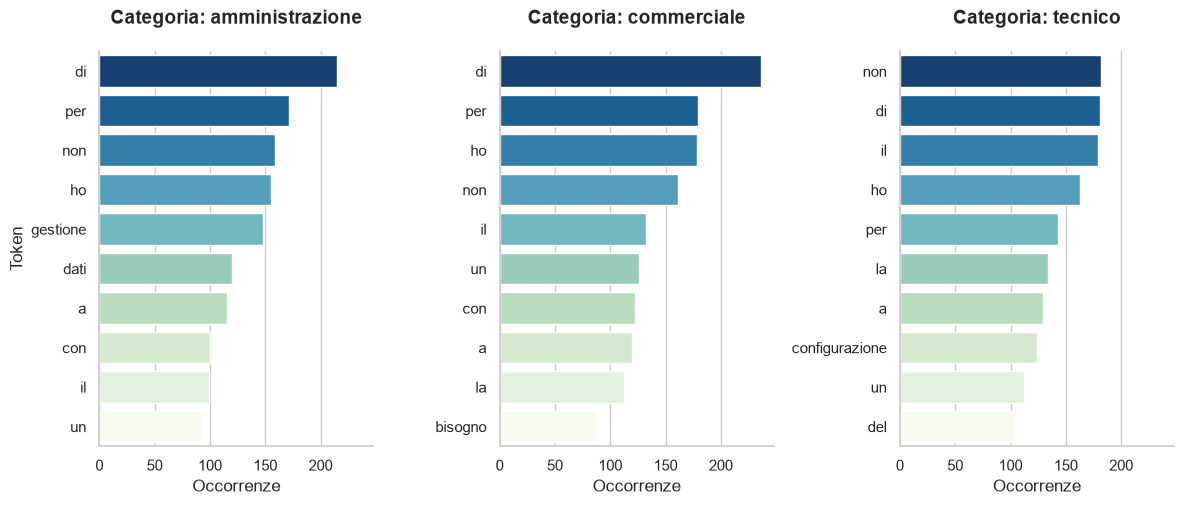

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
words_by_category = (df[['category', 'token']]
                     .explode('token')
                     .groupby(['category', 'token'])
                     .size()
                     .reset_index(name='Frequenza'))

#solo le top 10 parole per ogni singola categoria per non affollare il grafico
top_words_per_cat = (words_by_category
                     .sort_values(['category', 'Frequenza'], ascending=[True, False])
                     .groupby('category')
                     .head(10))

top_words_per_cat = top_words_per_cat.rename(columns={'token': 'Parola'})
top_words_per_cat['Word_Rank'] = top_words_per_cat.groupby('category').cumcount()
g = sns.catplot(
    data=top_words_per_cat, 
    kind="bar",
    x="Frequenza",  
    y="Parola",
    col="category",
    palette="GnBu_r",
    hue="Word_Rank",
    legend=False,
    sharey=False,
    height=5, 
    aspect=0.8
)

g.set_titles("Categoria: {col_name}", size=14, weight='bold',pad=20)
g.set_xlabels("Occorrenze", size=12)
g.set_ylabels("Token", size=12)


plt.show()

Come è possibile notare dal grafico, le parole più utilizzate sono prettamente stepword, ovvero parole che servono a costruire una frase, senza fornire ad essa un significato.

Nonostante questo possa sembrare un "rumore", il vettorizzatore che verrà presentato nella prossima frase risolve autonomamente questo problema, dato che il suo compito è quello di assegnare matematicamente un peso a tutte la parole; in particolare, questo abbassa in automatico le parole che compaiono in tutti i ticket. In ogni caso, verrà passato al vettorizzatore una lista base di stopword italiane proprio per aiutarlo in questo compito.

Facendo un piccolo passo in avanti, a seguito di vari test, questa operazione farà scendere leggermente la precisione nelle previsioni, ma di una percentuale altamente ignorabile. Considerando ciò che abbiamo detto pocanzi però, questo è un compromesso perfettamente accettabile al fine di rimuovere il rumore e concentrarci solo sulle parole realmente importanti per i ticket.

# Fase 3: Modello classificazione categoria:

Il problema da affrontare in questa fase è la creazione di codice per un modello che riesca a classificare la categoria di un ticket. 

A seguire è presente un analisi degli algoritmi utilizzati con una loro valutazione sul dataset scelto.

### Algoritmo di classificazione LinearSVC.

Citando Wikipedia:
- [Inglese](https://en.wikipedia.org/wiki/Support_vector_machine)
- [Italiano](https://it.wikipedia.org/wiki/Macchine_a_vettori_di_supporto)

"Le macchine a vettori di supporto (SVM, dall'inglese support-vector machines o networks) sono dei modelli di apprendimento supervisionato associati ad algoritmi di apprendimento per la regressione e la classificazione."

All'interno di questi modelli supervisionati, LinearSVC (Linear Support Vector Classifier) è una variante specializzata esclusivamente per compiti di classificazione in cui il confine tra le diverse categorie può essere tracciato mediante una linea retta 

Per poter utilizzare questo algoritmo, è stata necessario compiere un azione di vettorizzazione dei ticket. Viene sfruttata la libreria [*TfidfVectorizer*](https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.TfidfVectorizer.html), un ottima alleata per il problema in questione grazie alla sua capacità di trasformare il testo in vettori numerici pesati, evidenziando le parole chiave più rilevanti di ogni ticket ed escludendo il "rumore" di fondo della lingua parlata.

--- CLASSIFICATION REPORT - VALUTAZIONE CATEGORIA (Linear SVC) ---
Accuracy Totale: 0.8300

Report di Classificazione (comprende F1-Macro):
                 precision    recall  f1-score   support

amministrazione       0.85      0.91      0.88        32
    commerciale       0.78      0.81      0.79        36
        tecnico       0.86      0.78      0.82        32

       accuracy                           0.83       100
      macro avg       0.83      0.83      0.83       100
   weighted avg       0.83      0.83      0.83       100



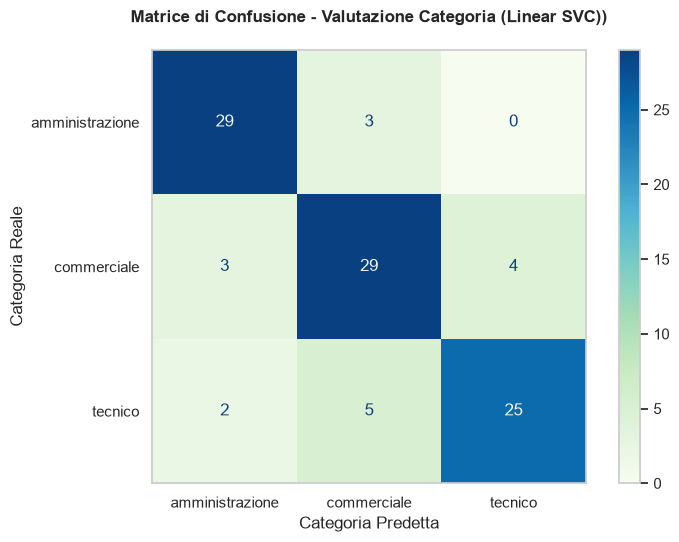

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

#definisco le Feature (X) e il Target (y) => non uso df['token'] perché TF-IDF effettua naturalmente una tokenizzazione
X = df['ticket_completo']
y = df['category']

#suddivisione in Train Set (80%) e Test Set (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.20, 
    random_state=42, 
    stratify=y
)
stop_italiane = ['di', 'a', 'da', 'in', 'con', 'su', 'per', 'tra', 'fra', 'il', 'lo', 'la', 'i', 'gli', 'le', 'un', 'uno', 'una', 'ho', 'non', 'e', 'del', 'della', 'dei', 'delle']
#estrazione delle Feature con TF-IDF
vectorizer_categoria = TfidfVectorizer(
    sublinear_tf=True, 
    min_df=5, 
    ngram_range=(1, 2), 
    stop_words=stop_italiane #inserendo le stopword italiane la precisione tende ad abbassarsi leggermente
)

#calcola il TF-IDF sui dati di Train e lo applichiamo al Test
X_train_tfidf = vectorizer_categoria.fit_transform(X_train)
X_test_tfidf = vectorizer_categoria.transform(X_test)

#addestramento del Modello (LinearSVC)
modello_categoria = LinearSVC(random_state=42, dual=False)
modello_categoria.fit(X_train_tfidf, y_train)

#predizione e Valutazione Base
y_pred = modello_categoria.predict(X_test_tfidf)

print("--- CLASSIFICATION REPORT - VALUTAZIONE CATEGORIA (Linear SVC) ---")
print(f"Accuracy Totale: {accuracy_score(y_test, y_pred):.4f}\n")
print("Report di Classificazione (comprende F1-Macro):")
print(classification_report(y_test, y_pred))

#matrice di confusione
cm = confusion_matrix(y_test, y_pred, labels=modello_categoria.classes_)

#visualizzazione grafica
fig, ax = plt.subplots(figsize=(8, 6),)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=modello_categoria.classes_)

disp.plot(cmap='GnBu', ax=ax, values_format='d')

#titoli formali
ax.set_title('Matrice di Confusione - Valutazione Categoria (Linear SVC))', fontsize=12, pad=20,fontweight='bold')
ax.grid(False)
ax.set_xlabel('Categoria Predetta', fontsize=12)
ax.set_ylabel('Categoria Reale', fontsize=12)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

## Algoritmo di classificazione Random Forest

Citando il sito [SnowFlake](https://www.snowflake.com/it/fundamentals/random-forest/):
- Random forest (foresta casuale) è uno degli algoritmi più potenti e diffusi utilizzati nella creazione di modelli di machine learning.
- Questo modello di apprendimento supervisionato costruisce numerosi alberi decisionali e combina le loro previsioni per produrre risultati più accurati e robusti.

Viene riutilizzato lo stesso vettorizzatore creato nella precedente cella di codice.

--- CLASSIFICATION REPORT - VALUTAZIONE CATEGORIA (Random Forest Classifier) ---
Accuracy Totale: 0.8400

                 precision    recall  f1-score   support

amministrazione       0.88      0.94      0.91        32
    commerciale       0.78      0.81      0.79        36
        tecnico       0.86      0.78      0.82        32

       accuracy                           0.84       100
      macro avg       0.84      0.84      0.84       100
   weighted avg       0.84      0.84      0.84       100



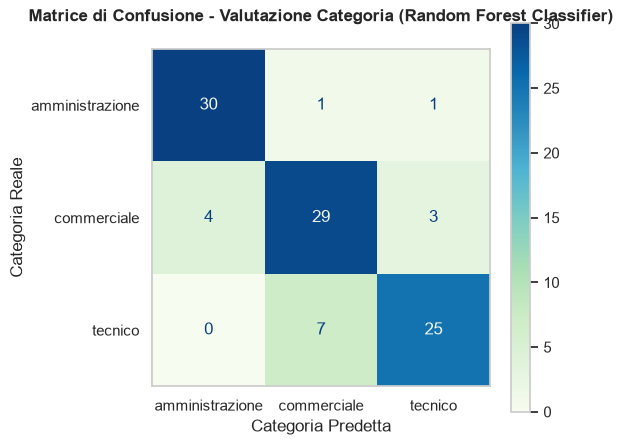

In [19]:
from sklearn.ensemble import RandomForestClassifier
labels_ordine = ['amministrazione', 'commerciale', 'tecnico']
print("--- CLASSIFICATION REPORT - VALUTAZIONE CATEGORIA (Random Forest Classifier) ---")
rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(X_train_tfidf, y_train)
y_pred_rf = rf_model.predict(X_test_tfidf)
print(f"Accuracy Totale: {accuracy_score(y_test, y_pred_rf):.4f}\n")
print(classification_report(y_test, y_pred_rf))
# Matrice di Confusione - Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf, labels=labels_ordine)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=labels_ordine)
fig, ax = plt.subplots(figsize=(6, 5))
disp_rf.plot(cmap='GnBu', ax=ax, values_format='d')
ax.set_title('Matrice di Confusione - Valutazione Categoria (Random Forest Classifier)', fontsize=12, pad=20,fontweight='bold')
ax.set_xlabel('Categoria Predetta', fontsize=12)
ax.set_ylabel('Categoria Reale', fontsize=12)
plt.grid(False)
plt.tight_layout()
plt.show()

# Fase 4: Modello valutazione priorità

Il problema da affrontare in questa fase è la creazione di codice per un modello che riesca a classificare la priorità di un ticket. 

Proprio come nella fase precedente, sono stati analizzati diversi algoritmi. A seguire è possibile consultarne l'elaborazione.

In più, è presentata l'analisi di una strategia di valutazione alternativa, che sfrutta i due algoritmi con un approccio gerarchico. *Questi saranno i modelli utilizzati nella dashboard in quanto hanno generato dei risultati più stabili e qualitativi.*

## Valutazione priorità con Linear SVC

--- CLASSIFICATION REPORT - VALUTAZIONE PRIORITÀ (Linear SVC) ---
Accuracy Totale: 0.6700

Report di Classificazione (comprende F1-Macro):
              precision    recall  f1-score   support

        alta       0.82      0.70      0.75        33
       bassa       0.69      0.77      0.73        35
       media       0.52      0.53      0.52        32

    accuracy                           0.67       100
   macro avg       0.68      0.67      0.67       100
weighted avg       0.68      0.67      0.67       100



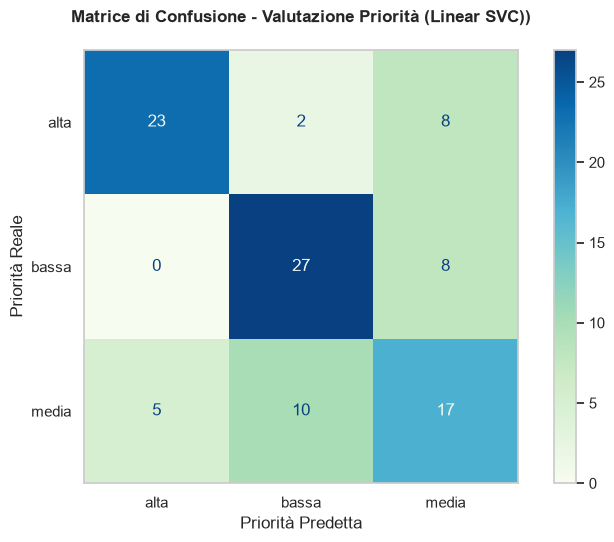

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

#definisco le Feature (X) e il Target (y) => non uso df['token'] perché TF-IDF effettua naturalmente una tokenizzazione
X = df['ticket_completo']
y = df['priority']

#suddivisione in Train Set (80%) e Test Set (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.20, 
    random_state=42, 
    stratify=y
)

#estrazione delle Feature con TF-IDF
vectorizer_priorità = TfidfVectorizer(
    sublinear_tf=True, 
    min_df=5, 
    ngram_range=(1, 2), 
    stop_words=stop_italiane #inserendo le stopword italiane con nltk il risultato peggiora
)

#calcola il TF-IDF sui dati di Train e lo applichiamo al Test
X_train_tfidf = vectorizer_priorità.fit_transform(X_train)
X_test_tfidf = vectorizer_priorità.transform(X_test)

#addestramento del Modello (LinearSVC)
modello_priorità = LinearSVC(random_state=42, dual=False)
modello_priorità.fit(X_train_tfidf, y_train)

#predizione e Valutazione Base
y_pred = modello_priorità.predict(X_test_tfidf)

print("--- CLASSIFICATION REPORT - VALUTAZIONE PRIORITÀ (Linear SVC) ---")
print(f"Accuracy Totale: {accuracy_score(y_test, y_pred):.4f}\n")
print("Report di Classificazione (comprende F1-Macro):")
print(classification_report(y_test, y_pred))

#matrice di confusione
cm = confusion_matrix(y_test, y_pred, labels=modello_priorità.classes_)

#visualizzazione grafica
fig, ax = plt.subplots(figsize=(8, 6),)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=modello_priorità.classes_)

disp.plot(cmap='GnBu', ax=ax, values_format='d')

#titoli formali
ax.set_title('Matrice di Confusione - Valutazione Priorità (Linear SVC))', fontsize=12, pad=20,fontweight='bold')
ax.grid(False)
ax.set_xlabel('Priorità Predetta', fontsize=12)
ax.set_ylabel('Priorità Reale', fontsize=12)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

## Valutazione priorità con Random Forest

--- CLASSIFICATION REPORT - VALUTAZIONE PRIORITÀ (Random Forest Classifier) ---
Accuracy Totale: 0.6600

              precision    recall  f1-score   support

        alta       0.75      0.82      0.78        33
       bassa       0.67      0.69      0.68        35
       media       0.54      0.47      0.50        32

    accuracy                           0.66       100
   macro avg       0.65      0.66      0.65       100
weighted avg       0.65      0.66      0.65       100



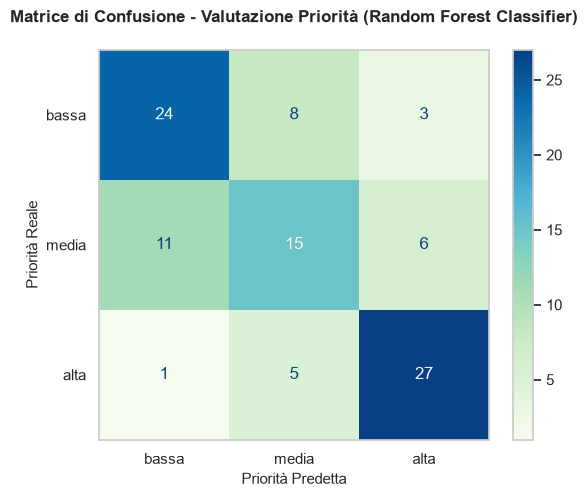

In [21]:
from sklearn.ensemble import RandomForestClassifier
labels_ordine = ['bassa', 'media', 'alta']
print("--- CLASSIFICATION REPORT - VALUTAZIONE PRIORITÀ (Random Forest Classifier) ---")
rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(X_train_tfidf, y_train)
y_pred_rf = rf_model.predict(X_test_tfidf)
print(f"Accuracy Totale: {accuracy_score(y_test, y_pred_rf):.4f}\n")
print(classification_report(y_test, y_pred_rf))
# Matrice di Confusione - Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf, labels=labels_ordine)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=labels_ordine)
fig, ax = plt.subplots(figsize=(6, 5))
disp_rf.plot(cmap='GnBu', ax=ax, values_format='d')
ax.set_title('Matrice di Confusione - Valutazione Priorità (Random Forest Classifier)', fontsize=12, pad=20,fontweight='bold')
ax.set_xlabel('Priorità Predetta', fontsize=11)
ax.set_ylabel('Priorità Reale', fontsize=11)
plt.grid(False)
plt.tight_layout()
plt.show()

## Valutazione priorità con approccio gerarchico usando Random Forest Classifier

Un altro approccio è stato quello di un addestramento gerarchico. Questa logica consiste nell'addestrare inizialmente il modello nella classificazione delle Categorie e poi addestrare in maniera verticale dei modelli di priorità per ogni reparto. 

Questa strategia ha aiutato i dataset in difficoltà a spiccare un pò di più sugli altri, e può risultare potenzialmente ancora più prestante in dataset di dimensioni maggiori in future implementazioni. Avendo a disposizione 500 ticket divisi in maniera equa (mediamente 166 ticket per tipo)


--- CLASSIFICATION REPORT - VALUTAZIONE PRIORITÀ (Approccio gerarchico Random Forest) ---
Accuracy Complessiva sulla Priorità: 0.6500

              precision    recall  f1-score   support

        Alta       0.76      0.85      0.80        33
       Bassa       0.68      0.54      0.60        35
       Media       0.51      0.56      0.54        32

    accuracy                           0.65       100
   macro avg       0.65      0.65      0.65       100
weighted avg       0.65      0.65      0.65       100



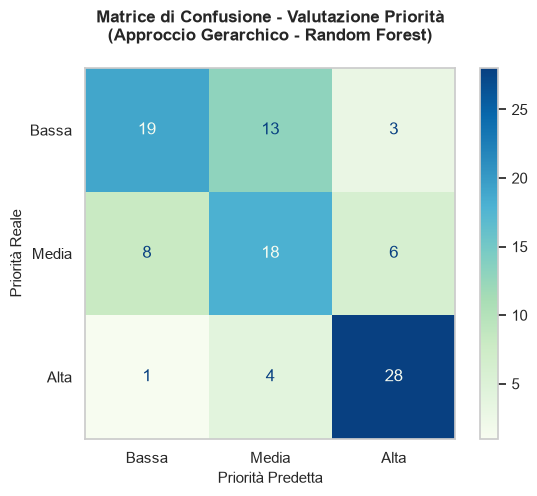

In [22]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier # <-- Importato Random Forest
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

#recupero dei dati
train_df = df.loc[X_train.index].copy()
test_df = df.loc[X_test.index].copy()

train_df['testo_completo'] = train_df['title'].fillna('') + " " + train_df['body'].fillna('')
test_df['testo_completo'] = test_df['title'].fillna('') + " " + test_df['body'].fillna('')
train_df['testo_completo'].map(clean_text)
test_df['testo_completo'].map(clean_text)
#--- FASE 1: Modello per le categorie ---
vec_cat_gerarchico = TfidfVectorizer(sublinear_tf=True, min_df=5, ngram_range=(1, 2), stop_words=stop_italiane)
X_train_cat_gerarchico = vec_cat_gerarchico.fit_transform(train_df['testo_completo'])
X_test_cat_gerarchico = vec_cat_gerarchico.transform(test_df['testo_completo'])

#utilizzo di RandomForestClassifier al posto di LinearSVC
mod_cat_gerarchico = RandomForestClassifier(random_state=42, n_estimators=100)
mod_cat_gerarchico.fit(X_train_cat_gerarchico, train_df['category'])

#predizione delle categorie (Tecnico, Amministrazione, Commerciale)
test_df['pred_category'] = mod_cat_gerarchico.predict(X_test_cat_gerarchico)

#--- FASE 2: Addestramento modelli di priorità verticali ---
elenco_categorie = train_df['category'].unique()

modelli_priorita_reparto = {}
vectorizers_priorita_reparto = {}

for cat in elenco_categorie:
    #filtra i dati del TRAIN SET per la categoria corrente
    train_sottogruppo = train_df[train_df['category'] == cat]
    
    vec_prio = TfidfVectorizer(sublinear_tf=True, min_df=2, ngram_range=(1, 2),stop_words=stop_italiane)
    X_train_prio_sub = vec_prio.fit_transform(train_sottogruppo['testo_completo'])
    
    #Random Forest con bilanciamento delle classi per gestire eventuali sbilanciamenti nelle priorità
    clf_prio_sub = RandomForestClassifier(random_state=42, n_estimators=100, class_weight='balanced')
    clf_prio_sub.fit(X_train_prio_sub, train_sottogruppo['priority'])
    
    modelli_priorita_reparto[cat.lower().strip()] = clf_prio_sub
    vectorizers_priorita_reparto[cat.lower().strip()] = vec_prio

#--- FASE 3: Pipeline gerarchico del test set ---
priorita_predette_finali = []

for idx, riga in test_df.iterrows():
    categoria_stimata = str(riga['pred_category']).lower().strip()
    testo_ticket = riga['testo_completo']
    
    if categoria_stimata in vectorizers_priorita_reparto:
        vettorizzatore_specifico = vectorizers_priorita_reparto[categoria_stimata]
        modello_specifico = modelli_priorita_reparto[categoria_stimata]
        
        testo_vettorizzato = vettorizzatore_specifico.transform([testo_ticket])
        prio_stimata = modello_specifico.predict(testo_vettorizzato)[0]
    else:
        prio_stimata = riga['priority'] 
        
    priorita_predette_finali.append(prio_stimata)

test_df['pred_priority'] = priorita_predette_finali

#--- VALUTAZIONE ---
print("\n" + "="*60)
print("--- CLASSIFICATION REPORT - VALUTAZIONE PRIORITÀ (Approccio gerarchico Random Forest) ---")
print("="*60)

#garantiamo la corrispondenza esatta delle stringhe
test_df['priority'] = test_df['priority'].str.strip().str.capitalize()
test_df['pred_priority'] = test_df['pred_priority'].str.strip().str.capitalize()

acc_prio = accuracy_score(test_df['priority'], test_df['pred_priority'])
print(f"Accuracy Complessiva sulla Priorità: {acc_prio:.4f}\n")
print(classification_report(test_df['priority'], test_df['pred_priority']))

#matrice di Confusione
labels_ordine = ['Bassa', 'Media', 'Alta']
cm = confusion_matrix(test_df['priority'], test_df['pred_priority'], labels=labels_ordine)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels_ordine)
disp.plot(cmap='GnBu', ax=ax, values_format='d')
plt.title('Matrice di Confusione - Valutazione Priorità\n(Approccio Gerarchico - Random Forest)', fontsize=12, pad=20, fontweight='bold')
ax.set_xlabel('Priorità Predetta', fontsize=11)
ax.set_ylabel('Priorità Reale', fontsize=11)
plt.grid(False)
plt.tight_layout()
plt.show()

## Valutazione priorità con approccio gerarchico usando Linear SVC


--- CLASSIFICATION REPORT - VALUTAZIONE PRIORITÀ (Approccio gerarchico LinearSVC) ---
Accuracy Complessiva sulla Priorità: 0.7300

              precision    recall  f1-score   support

        Alta       0.83      0.76      0.79        33
       Bassa       0.74      0.80      0.77        35
       Media       0.62      0.62      0.62        32

    accuracy                           0.73       100
   macro avg       0.73      0.73      0.73       100
weighted avg       0.73      0.73      0.73       100



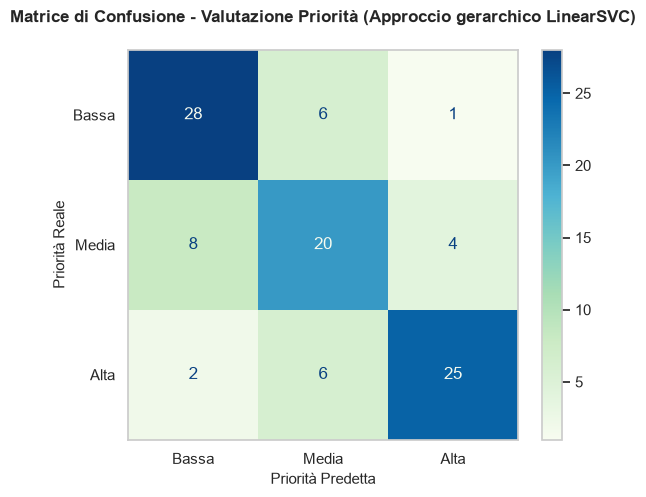

In [23]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

#recupero dei dati
train_df = df.loc[X_train.index].copy()
test_df = df.loc[X_test.index].copy()

train_df['testo_completo'] = train_df['title'].fillna('') + " " + train_df['body'].fillna('')
test_df['testo_completo'] = test_df['title'].fillna('') + " " + test_df['body'].fillna('')
train_df['testo_completo'].map(clean_text)
test_df['testo_completo'].map(clean_text)

#modello per la categorie
vec_cat_gerarchico = TfidfVectorizer(sublinear_tf=True, min_df=5, ngram_range=(1, 2), stop_words=stop_italiane)
X_train_cat_gerarchico = vec_cat_gerarchico.fit_transform(train_df['testo_completo'])
X_test_cat_gerarchico = vec_cat_gerarchico.transform(test_df['testo_completo'])

mod_cat_gerarchico = LinearSVC(random_state=42, dual=False)
mod_cat_gerarchico.fit(X_train_cat_gerarchico, train_df['category'])

#predizione delle categorie (Tecnico, Amministrazione, Commerciale)
test_df['pred_category'] = mod_cat_gerarchico.predict(X_test_cat_gerarchico)

#addestramento modelli di priorità per la categoria
elenco_categorie = train_df['category'].unique()

modelli_priorita_reparto = {}
vectorizers_priorita_reparto = {}

for cat in elenco_categorie:
    #filtra i dati del TRAIN SET per la categoria corrente
    train_sottogruppo = train_df[train_df['category'] == cat]
    
    vec_prio = TfidfVectorizer(sublinear_tf=True, min_df=2, ngram_range=(1, 2),stop_words=stop_italiane)
    X_train_prio_sub = vec_prio.fit_transform(train_sottogruppo['testo_completo'])
    
    clf_prio_sub = LinearSVC(random_state=42, dual=False, class_weight='balanced')
    clf_prio_sub.fit(X_train_prio_sub, train_sottogruppo['priority'])
    
    modelli_priorita_reparto[cat.lower().strip()] = clf_prio_sub
    vectorizers_priorita_reparto[cat.lower().strip()] = vec_prio

#pipeline gerarchico del test set
priorita_predette_finali = []

for idx, riga in test_df.iterrows():
    categoria_stimata = str(riga['pred_category']).lower().strip()
    testo_ticket = riga['testo_completo']
    
    if categoria_stimata in vectorizers_priorita_reparto:
        vettorizzatore_specifico = vectorizers_priorita_reparto[categoria_stimata]
        modello_specifico = modelli_priorita_reparto[categoria_stimata]
        
        testo_vettorizzato = vettorizzatore_specifico.transform([testo_ticket])
        prio_stimata = modello_specifico.predict(testo_vettorizzato)[0]
    else:
        prio_stimata = riga['priority'] 
        
    priorita_predette_finali.append(prio_stimata)

test_df['pred_priority'] = priorita_predette_finali

#valutazione dell'approccio gerarchico
print("\n" + "="*60)
print("--- CLASSIFICATION REPORT - VALUTAZIONE PRIORITÀ (Approccio gerarchico LinearSVC) ---")
print("="*60)

# Garantiamo la corrispondenza esatta delle stringhe per evitare il ValueError nella matrice
test_df['priority'] = test_df['priority'].str.strip().str.capitalize()
test_df['pred_priority'] = test_df['pred_priority'].str.strip().str.capitalize()

acc_prio = accuracy_score(test_df['priority'], test_df['pred_priority'])
print(f"Accuracy Complessiva sulla Priorità: {acc_prio:.4f}\n")
print(classification_report(test_df['priority'], test_df['pred_priority']))

# Matrice di Confusione protetta
labels_ordine = ['Bassa', 'Media', 'Alta']
cm = confusion_matrix(test_df['priority'], test_df['pred_priority'], labels=labels_ordine)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels_ordine)
disp.plot(cmap='GnBu', ax=ax, values_format='d')
plt.title('Matrice di Confusione - Valutazione Priorità (Approccio gerarchico LinearSVC)', fontsize=12, pad=20,fontweight='bold')
ax.set_xlabel('Priorità Predetta', fontsize=11)
ax.set_ylabel('Priorità Reale', fontsize=11)
plt.grid(False)
plt.tight_layout()
plt.show()

# Fase 5: Esportazione dei Modelli

I modelli e vettorizzatori esportati sono quelli che hanno mostrato risultati più consistenti partendo dal dataset generato con Gemma4:e2b. Vengono conservati nella cartella modelli, e verranno utilizzati nello script 04_Dashboard.py per eseguire una web app di facile utilizzo per dei potenziali futuri operatori.

In [ ]:
import joblib

#salviamo i componenti chiave del sistema
joblib.dump(mod_cat_gerarchico, 'modelli/m_categoria.pkl')
joblib.dump(vec_cat_gerarchico, 'modelli/v_categoria.pkl')

#salviamo anche i dizionari dei modelli verticali delle priorità
joblib.dump(modelli_priorita_reparto, 'modelli/m_priorità.pkl')
joblib.dump(vectorizers_priorita_reparto, 'modelli/v_priorità.pkl')

print("Tutti i modelli e i vettorizzatori sono stati serializzati con successo!")

Tutti i modelli e i vettorizzatori sono stati serializzati con successo!


# Fase 6: Valutazione generale dei vari modelli nei dataset analizzati e possibili miglioramenti

In questa ultima fase vengono analizzati i risultati ricevuti eseguendo la pipeline presente in questo Notebook nei vari dataset.

Come prima cosa, una breve descrizione dei dataset analizzati:
- **pseudorandom**: Il dataset creato seguendo la pipeline del primo notebook. La sua realizzazione avviene grazie ad un algoritmo che estrae in maniera pseudocasuale verbi e parole chiave per ogni argomento e categoria al fine di realizzare dei ticket immaginari. Per sua struttura, presenta meno ticket con priorità alta per simulare lo sbilanciamento di richieste che si creerebbe nella vita reale;
- **gemma4_unbalanced**: Il primo dei dataset realizzati con Gemma4, dove ho creato dei ticket realizzando in un ciclo la generazione di prompt ad hoc (procedura analizzata nel dettaglio nel secondo notebook). Proprio come il dataset pseudorandom, questo presenta uno sbilanciamento di ticket a priorità alta;
- **gemma4_balanced**: Il secondo dataset realizzato con Gemma4. Questa volta, la quantità di ticket a priorità alta, media o bassa è bilanciata e completamente casuale;
- **gemma4e2b**: Dataset realizzato con Gemma4:e2b, una versione più leggera di Gemma4 con molti parametri in meno, cosa che ha permesso di creare dei ticket meno complessi.
- **unione_di_tutti**: Come dice il nome, in questo dataset ho unito e mischiato tutti i ticket presenti nei dataset precedenti, così da formare un dataset contenente 2000 ticket.

Nella tabella a seguire è possibile consultare una piccola tabella che riassume i migliori valori di accuracy per categoria e priorità ricavati, insieme all'algoritmo che ha realizzato il risultato.

| Dataset | Accuracy Categoria | Accuracy Priorità | Note
| :--- | :---: | :---: | :---: | 
| pseudorandom | 0.89 con LinearSVC | 0.86 RandomForest | Numeri alti sovrastimati dalla pseudocasualità, generalizzando male sui ticket veri (overfitting) |
| gemma4_unbalanced | 0.73 con LinearSVC | 0.54 con Approccio Gerarchico| Risultati pessimi dovuti dallo sbilanciamento del numero di ticket per gruppo di priorità e dalla complessità di Gemma4|
| gemma4_balanced | 0.82 con LinearSVC | 0.53 con Approccio Gerarchico| Anche qui, risultati pessimi dovuti dalla complessità di Gemma4.  |
| gemma4e2b | 0.84 con Random Forest | 0.73 con Approccio Gerarchico| Molto solido e bilanciato, il più robusto |
| unione_di_tutti | 0.93 con LinearSVC | 0.80 con LinearSVC | È il vincitore morale. Ha l'accuratezza più alta sulla Categoria e un ottimo 0.80 sulla Priorità, ma è un dataset che contiene tutti i ticket insieme(2000 ticket), quindi da non considerare perché esce fuori dalle specifiche richieste del PW |

Nonostante il modello addestrato con il dataset pseudorandom mostri valori più alti, lo considero meno indicato in quanto allenato su dati più semplici e ripetitivi.

Dunque, il risultato più stabile lo da sicuramente l'algoritmo Random Forest con il dataset gemma4e2b. Questo risultato lo si deve soprattutto grazie alla funzione *remove_key_word* che ha rimosso una pesante instabilità nel risultato finale per quanto riguarda l'accuracy della categoria (0.98), cosa che dimostrava un grosso problema di overfitting a causa della presenza di parole chiavi come "amministrazione", "tecnico", ecc...

Per questo motivo, saranno il modello e il vettorizzatore generati da gemma4e2b a essere utilizzati per la creazione dell'ultimo punto del PW : una dashboard con output categoria prevista, priorità suggerita e 5 parole più influenti. Sarà possibile vedere il codice nel quarto e ultimo notebook.

Come è possibile notare dalla tabella, la sezione in cui la pipeline ha portato risultati più deboli è sicuramente quella inerente alla valutazione della priorità.

Il codice a seguire permette un analisi delle parole più influenti per ogni classe (ovvero le 10 parole con il coefficiente positivo più alto per le varie categorie e le varie priorità).

## Top 10 parole più influenti per la categoria:

In questo caso, per mantere la pipeline pulita e ordinata, verranno mostrate le feature generate dall'algoritmo LinearSVC.

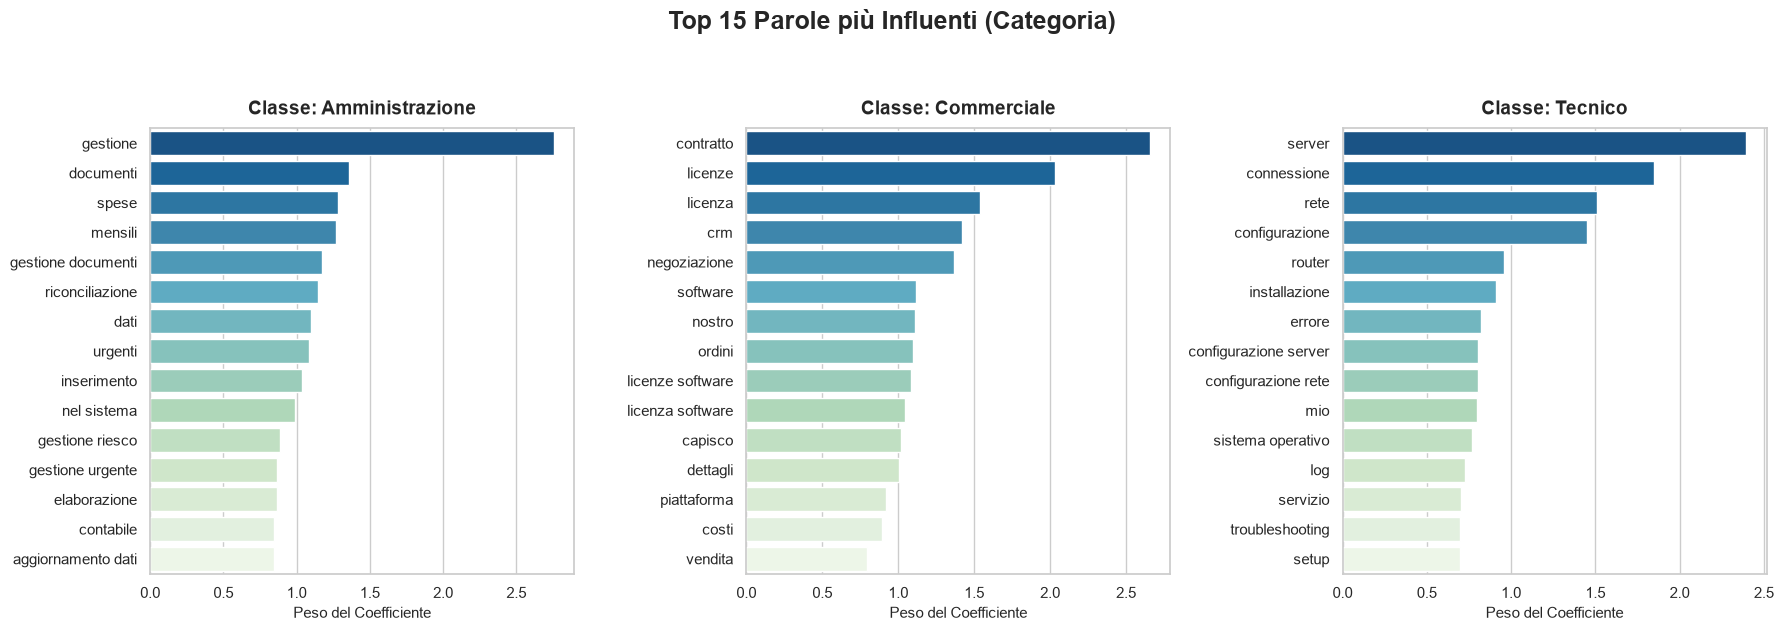

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

#recupera le feature e i coefficienti dal modello
feature_names = np.array(vectorizer_categoria.get_feature_names_out())
coefficients = modello_categoria.coef_
class_labels = modello_categoria.classes_

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharex=False)
fig.suptitle('Top 15 Parole più Influenti (Categoria)', fontsize=18, fontweight='bold', y=1.05)

palette = sns.color_palette("GnBu_r", 15)

for i, class_label in enumerate(class_labels):
    #trova i primi 15 indici con coefficiente positivo più alto
    top_indices = np.argsort(coefficients[i])[::-1][:15]
    
    top_words = feature_names[top_indices]
    top_coefs = coefficients[i][top_indices]
    
    df_temp = pd.DataFrame({
        'Parola': top_words,
        'Coefficiente': top_coefs
    })
    
    #disegna il grafico a barre orizzontali sul sotto-grafico corrente
    sns.barplot(
        data=df_temp,
        x='Coefficiente',
        y='Parola',
        ax=axes[i],
        palette=palette,
        hue='Parola',
        legend=False
    )
    
    axes[i].set_title(f"Classe: {class_label.capitalize()}", fontsize=14, fontweight='bold', pad=10)
    axes[i].set_xlabel("Peso del Coefficiente", fontsize=11)
    axes[i].set_ylabel("", fontsize=11)
    axes[i].tick_params(axis='y', labelsize=11) #singoli token

plt.tight_layout()
plt.show()

## Top 10 parole più influenti per la priorità

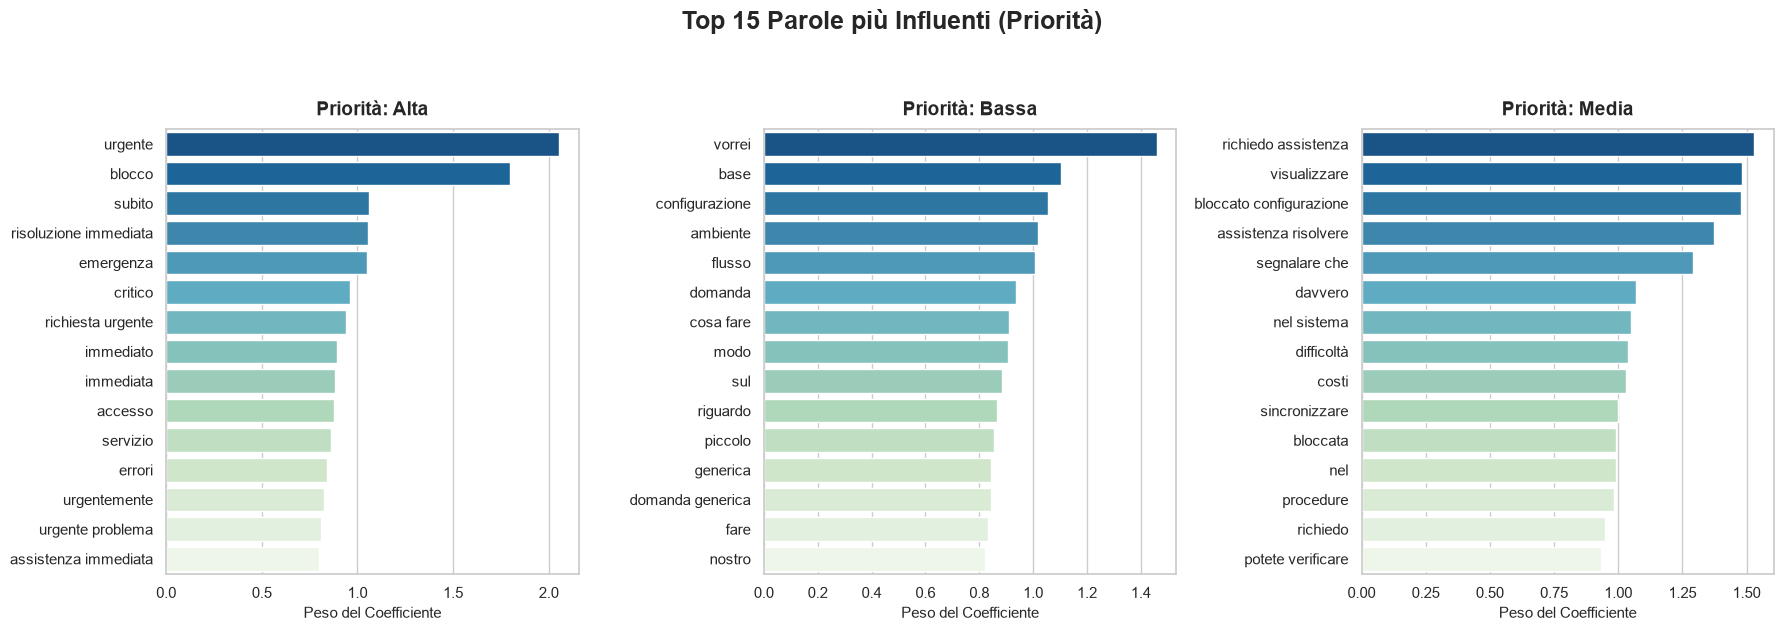

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

feature_names = np.array(vectorizer_priorità.get_feature_names_out())

coefficients = modello_priorità.coef_
class_labels = modello_priorità.classes_

num_classi = len(class_labels)

fig, axes = plt.subplots(1, num_classi, figsize=(6 * num_classi, 6), sharex=False)
fig.suptitle('Top 15 Parole più Influenti (Priorità)', fontsize=18, fontweight='bold', y=1.05)

palette = sns.color_palette("GnBu_r", 15)

for i, class_label in enumerate(class_labels):
    top_indices = np.argsort(coefficients[i])[::-1][:15]
    
    top_words = feature_names[top_indices]
    top_coefs = coefficients[i][top_indices]
    
    df_temp = pd.DataFrame({
        'Parola': top_words,
        'Coefficiente': top_coefs
    })
    
    sns.barplot(
        data=df_temp,
        x='Coefficiente',
        y='Parola',
        ax=axes[i],
        palette=palette,
        hue='Parola',       
        legend=False
    )
    
    axes[i].set_title(f"Priorità: {class_label.capitalize()}", fontsize=14, fontweight='bold', pad=10)
    axes[i].set_xlabel("Peso del Coefficiente", fontsize=11)
    axes[i].set_ylabel("", fontsize=11)
    axes[i].tick_params(axis='y', labelsize=11)

plt.tight_layout()
plt.show()

In conclusione, grazie all'ausilio grafico, è possibile notare come ogni categoria / priorità abbia un insieme di parole chiave eterogenee. Questo significa che gli algoritmi si sono adattati perfettamente al dataset!

## Possibili futuri miglioramenti

Da quest'ultima analisi, emerge anche la presenza di token semanticamente sovrapponibili ma morfologicamente distinti, come i singolari e plurali dei termini chiave, differenza maschile e femminile (es. 'immediato' / 'immediata', 'licenza' / 'licenze').

Questo fenomeno è facilmente risolvibile come potenziale futuro miglioramento grazie ad un operazione di **lemmatizzazione** (riduzione alla forma canonica o lemma) o uno **stemming avanzato** rispetto a quello utilizzato all'interno della pipeline di preprocessing. 

Altre potenziali modifiche future potrebbero essere modifiche dei **parametri chiave utilizzati**. Nella pipeline attuale, i parametri utilizzati sono abbastanza generici e standard, ma potrebbero essere modificati per massimizzare la generalizzazione, ad esempio:

- *Random Forest*: Esplorazione della profondità massima (max_depth) per prevenire l'overfitting sui testi di training, e l'ottimizzazione del numero minimo di campioni per foglia (min_samples_leaf) per migliorare le regole decisionali.

- *LinearSVC*: Variazione del parametro di regolarizzazione (C). Un valore di C ottimizzato potrebbe permettere di trovare il giusto compromesso tra un margine di separazione ampio (che generalizza meglio) e la corretta classificazione dei ticket più ambigui nel training set.

Un altro potenziale sviluppo futuro per questo progetto consiste nel superamento dell'approccio TF-IDF attraverso l'utilizzo di **BERT** (Bidirectional Encoder Representations from Transformers), un modello di Deep Learning sviluppato da Google e basato sull'architettura Transformer ([link per approfondimento](https://www.snowflake.com/it/fundamentals/bert/)).

A differenza dei modelli creati in questa pipeline, BERT è pre-addestrato su enormi quantità di testo e analizza le frasi in modo bidirezionale (leggendo contemporaneamente il contesto a destra e a sinistra di ogni parola). L'integrazione di questa architettura potrebbe garantire due netti miglioramenti:

- Risoluzione delle ambiguità: BERT è in grado di comprendere il significato del termine in base al contesto in cui si trova. Es: distinguerebbe la frase 'reset del router' (ticket Tecnico) dalla frase 'reset del contratto' (ticket Commerciale).

- Comprensione semantica profonda: Per sua natura questo modello riesce a riconoscere sinonimi o termini affini (es: 'urgente', 'critico', 'immediato', ecc...). Questo permetterebbe di incrementare la precisione sulla classificazione delle priorità, che è l'area in cui l'attuale pipeline ha mostrato i margini di miglioramento più ampi.